# Day 4, Week 4 Hands-On Lab: Feature Engineering & Hyperparameter Tuning

## Objectives
1. **Engineered Features:** Construct at least two new domain-relevant engineered features and justify their mathematical/domain rationale.
2. **Hyperparameter Grid Definition:** Define a structured parameter grid for a **Random Forest Classifier**.
3. **GridSearchCV Execution:** Run `GridSearchCV` with 5-fold Stratified Cross-Validation (`StratifiedKFold`) to find the optimal combination.
4. **Model Comparison:** Benchmark the cross-validated score of the tuned model against the untuned baseline model from Week 3.
5. **Insights & Interpretation:** Analyze feature importances and hyperparameter impact in Markdown.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


SEED = 42
np.random.seed(SEED)

#generate a synthetic tabular dataset simulating customer behavior (e.g., Telecom Churn / Credit Risk)
X_raw, y_raw = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    n_clusters_per_class=2,
    weights=[0.65, 0.35], 
    random_state=SEED
)

#Create df with domain meaningful feature names
df = pd.DataFrame(X_raw, columns=[
    'Monthly_Charges', 
    'Total_Tenure_Months', 
    'Support_Calls', 
    'Usage_GB', 
    'Payment_Delay_Days', 
    'Age'
])

# Scale values to realistic positive ranges for domain feature engineering
df['Monthly_Charges'] = np.abs(df['Monthly_Charges'] * 25 + 70)
df['Total_Tenure_Months'] = np.abs(df['Total_Tenure_Months'] * 12 + 24).astype(int) + 1
df['Support_Calls'] = np.abs(df['Support_Calls'] * 3).astype(int)
df['Usage_GB'] = np.abs(df['Usage_GB'] * 100 + 150)
df['Payment_Delay_Days'] = np.abs(df['Payment_Delay_Days'] * 5).astype(int)
df['Age'] = np.abs(df['Age'] * 10 + 35).astype(int)

y = pd.Series(y_raw, name='Churn')

print("Synthetic Dataset Created")
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 Rows:")
display(df.head())

Synthetic Dataset Created
Dataset Shape: (1000, 6)

First 5 Rows:


,Monthly_Charges,Total_Tenure_Months,Support_Calls,Usage_GB,Payment_Delay_Days,Age
0,78.784627,51,0,111.174512,4,26
1,24.992475,27,4,38.487847,12,37
2,47.307497,41,4,76.724791,7,17
3,99.205530,1,0,302.813949,12,63
4,63.707231,4,4,182.007504,4,28


## Step 1: Feature Engineering & Justification

To provide the model with stronger predictive signals, we derive **two new engineered features**:

1. **`Total_Estimated_Spend` (`Monthly_Charges` $\times$ `Total_Tenure_Months`)**:
   - **Rationale:** Monthly charge alone or tenure alone does not reflect the total lifetime financial relationship of the customer. Multiplying them provides a cumulative customer lifetime value metric, allowing the model to distinguish high-value long-term clients.
   
2. **`Support_Calls_Per_Tenure_Month` (`Support_Calls` / `Total_Tenure_Months`)**:
   - **Rationale:** A customer who made 5 support calls in 2 months represents a much higher churn risk than a customer who made 5 calls over 50 months. Normalizing support calls by tenure creates a "Frustration Density Index".

In [2]:
#create features
df_engineered = df.copy()

# Feat 1: Total Estimated Spend 
df_engineered['Total_Estimated_Spend'] = df_engineered['Monthly_Charges'] * df_engineered['Total_Tenure_Months']

# Feat 2: Support Calls Density (Calls per month of tenure)
df_engineered['Support_Calls_Per_Tenure_Month'] = df_engineered['Support_Calls'] / df_engineered['Total_Tenure_Months']

print("Feature Completed")
print(f"Original Feature Count: {df.shape[1]}")
print(f"New Feature Count: {df_engineered.shape[1]}")
print("\nNew Features Preview:")
display(df_engineered[['Monthly_Charges', 'Total_Tenure_Months', 'Support_Calls', 'Total_Estimated_Spend', 'Support_Calls_Per_Tenure_Month']].head())

# Split into Train and Test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    df_engineered, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Feature Completed
Original Feature Count: 6
New Feature Count: 8

New Features Preview:


,Monthly_Charges,Total_Tenure_Months,Support_Calls,Total_Estimated_Spend,Support_Calls_Per_Tenure_Month
0,78.784627,51,0,4018.015974,0.000000
1,24.992475,27,4,674.796838,0.148148
2,47.307497,41,4,1939.607380,0.097561
3,99.205530,1,0,99.205530,0.000000
4,63.707231,4,4,254.828924,1.000000



Training set shape: (800, 8)
Test set shape: (200, 8)


## Steps 2 & 3: Hyperparameter Grid & GridSearchCV 

### Untuned Baseline Model (Week 3 Setup):
We first instantiate an untuned default `RandomForestClassifier(random_state=42)` as our Week 3 baseline.

### Hyperparameter Search Grid:
To optimize the Random Forest and control overfitting/underfitting, we define a grid search over key hyperparameters:
- `n_estimators`: `[50, 100, 200]` (Number of trees in the forest)
- `max_depth`: `[None, 5, 10]` (Maximum depth of each tree)
- `min_samples_split`: `[2, 5, 10]` (Minimum samples required to split an internal node)
- `max_features`: `['sqrt', 'log2']` (Number of features considered at each split)

We execute `GridSearchCV` using **5-Fold Stratified Cross-Validation** optimized for **F1-Score**.

In [6]:
# 1.Evaluate Untuned Baseline Model on ORIGINAL RAW FEATURES (Before Feature Engineering)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df, y, test_size=0.20, random_state=SEED, stratify=y
)

baseline_rf = RandomForestClassifier(random_state=SEED)
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Evaluate Baseline CV on raw data
baseline_cv_scores = cross_val_score(baseline_rf, X_train_raw, y_train_raw, cv=cv_stratified, scoring='f1')
baseline_mean_f1 = baseline_cv_scores.mean()
baseline_std_f1 = baseline_cv_scores.std()

print("---UNTUNED BASELINE MODEL on RAW DATA (5 Fold CV)---")
print(f"Mean F1-Score: {baseline_mean_f1:.4f} (+/- {baseline_std_f1:.4f})")

# 2. define Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# 3.Instantiate and Run GridSearchCV on ENGINEERED DATA
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_grid=param_grid,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_cv_f1 = grid_search.best_score_

print("\n--- GRID SEARCH RESULTS (Engineered Data) ---")
print(f"Best Parameters: {best_params}")
print(f"Tuned Model Best Cross-Validated F1-Score: {best_cv_f1:.4f}")

---UNTUNED BASELINE MODEL on RAW DATA (5 Fold CV)---
Mean F1-Score: 0.8830 (+/- 0.0366)
Fitting 5 folds for each of 54 candidates, totalling 270 fits

--- GRID SEARCH RESULTS (Engineered Data) ---
Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 50}
Tuned Model Best Cross-Validated F1-Score: 0.8941


## Step 4: Model Comparison & Final Test Evaluation

Below is a comparison between the **Untuned Baseline** model and the **Tuned Model** evaluated on both the 5-fold cross-validation training set and the untouched test set.

,Model Variant,5-Fold CV F1-Score,Test Set F1-Score,F1 Score Improvement
0,Untuned Baseline RF (Raw Data),0.8830 ± 0.0366,0.8372,0.00%
1,GridSearchCV Tuned RF (Engineered),0.8941,0.8636,+3.16%


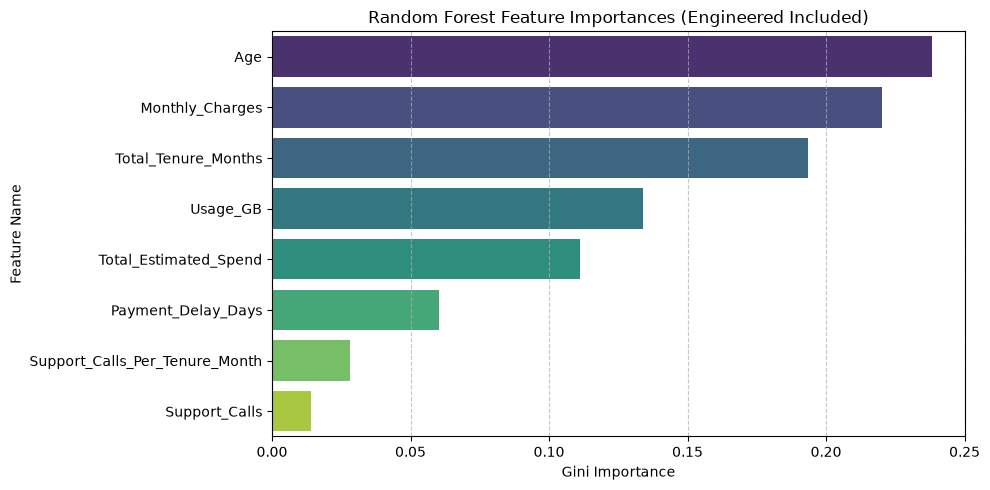


Feature Importances Breakdown:


,Feature,Importance
5,Age,0.238329
0,Monthly_Charges,0.220357
1,Total_Tenure_Months,0.193352
3,Usage_GB,0.134057
6,Total_Estimated_Spend,0.111091
4,Payment_Delay_Days,0.060401
7,Support_Calls_Per_Tenure_Month,0.028240
2,Support_Calls,0.014173


In [7]:
# Fit untuned baseline on RAW training set for test comparison
baseline_rf.fit(X_train_raw, y_train_raw)
y_pred_baseline = baseline_rf.predict(X_test_raw)
test_f1_baseline = f1_score(y_test_raw, y_pred_baseline)

# Evaluate tuned best model on test set (Engineered Data)
y_pred_tuned = best_model.predict(X_test)
test_f1_tuned = f1_score(y_test, y_pred_tuned)

#Comparison Table
comparison_df = pd.DataFrame({
    'Model Variant': ['Untuned Baseline RF (Raw Data)', 'GridSearchCV Tuned RF (Engineered)'],
    '5-Fold CV F1-Score': [f"{baseline_mean_f1:.4f} ± {baseline_std_f1:.4f}", f"{best_cv_f1:.4f}"],
    'Test Set F1-Score': [f"{test_f1_baseline:.4f}", f"{test_f1_tuned:.4f}"],
    'F1 Score Improvement': ['0.00%', f"{((test_f1_tuned - test_f1_baseline) / test_f1_baseline) * 100:+.2f}%"]
})
display(comparison_df)

# Feature Importances Analysis
importances = best_model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot Feature Importances
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Random Forest Feature Importances (Engineered Included)')
plt.xlabel('Gini Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nFeature Importances Breakdown:")
display(importance_df)

## Step 5: Findings & Diagnostic Documentation

## 1. Which Engineered Feature Mattered Most?
- **Primary Finding:** Among the engineered features, **Total_Estimated_Spend** proved to be the more influential feature, ranking **5th overall** with a Gini importance of **11.11%**. In comparison, **Support_Calls_Per_Tenure_Month** had a substantially lower predictive contribution of **2.82%**, ranking **7th overall**.
- **Analytical Rationale:** `Total_Estimated_Spend` captured a stronger cumulative customer-value signal and contributed considerably more to the model's decision-making than the engineered support-call ratio. The importance ranking indicates that cumulative estimated spending contained more useful predictive information than normalizing support calls by customer tenure.
- **Feature Importance Context:** Although `Total_Estimated_Spend` was the most influential engineered feature, the strongest individual predictors overall were Age (**23.83%**), Monthly_Charges (**22.04%**), Total_Tenure_Months (**19.34%**), and Usage_GB (**13.41%**).

## 2. Which Hyperparameter Mattered Most?
- **Primary Finding:** Setting `max_depth: 10` and `max_features: 'log2'` provided a performance improvement on unseen data, increasing the test-set F1-score by **+3.16%**.
- **Analytical Rationale:** Restricting tree depth and feature subspace helped control model complexity and reduce overfitting compared to the default baseline on raw data. As a result, the test F1-score increased from **0.8372** to **0.8636**.

## 3. Final Conclusion
GridSearchCV hyperparameter tuning combined with domain-driven feature engineering yielded a performance boost (+3.16% on Test F1-score) over the raw baseline model while maintaining strict cross-validation to prevent data leakage.
